# Trajectory Examples
1. Generation with moon (or custom body)
2. EKF on simply noisy position measurements
3. UKF on simply noisy position measurements
4. PF on simply noisy position measurements? idk idk

## Generation

In [1]:
from pathlib import Path
import sys
parent_dir = Path.cwd().parent.resolve()
sys.path.append(str(parent_dir))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import trajectory as T
from Constants import G, Luna
from utils import circle_points
from filters import SatEKF

PlanetaryData: Make sure to update position of bodies with position at specific time
e.g. `Earth["position"] = [1.0, 2.0, 3.0]  # km`


In [3]:
body = Luna # could be moon

body = { # Custom central body
    "radius": 3000e3, # m
    "mass": 6e23, # kg
    "mu": 6e23 * G,
    "position": [0,0,0]
}

# State
r = 1500e3 + body["radius"]
v = np.sqrt(body["mu"] / r)
state0 = [
    r, 0, 0,
    0, v, 0]

# Time
dt = 0.1

# Simulating Half an orbit
orb_period = 2 * np.pi * np.sqrt(r*r*r/body["mu"])
print(f"Orbital period (T): {orb_period}s")
tf = orb_period / 2

Orbital period (T): 9478.231454433602s


In [4]:
# Propagator
op = T.OrbitPropagator(state0, tf, dt, [body])
op.simulate()

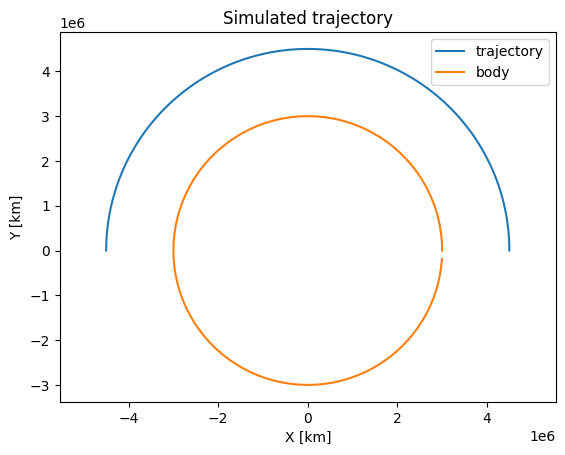

In [5]:
plt.title("Simulated trajectory")
plt.plot(op.states[:,0], op.states[:,1])
plt.plot(*circle_points(body["radius"], position=body["position"][0:2]))
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend(["trajectory", "body"])
plt.axis('equal')
plt.show()

## EKF on position measurements



In [ ]:
dt = 1.0  # s
sigma_a = 1e-2  # m/s^2
Q = np.block([
    [ (dt**3/3) * sigma_a**2 * np.eye(3), (dt**2/2) * sigma_a**2 * np.eye(3) ],
    [ (dt**2/2) * sigma_a**2 * np.eye(3), dt * sigma_a**2 * np.eye(3) ]
])

ekf = SatEKF()

TypeError: SatEKF.__init__() missing 6 required positional arguments: 'Q', 'R', 'dt', 'mu0', 'sigma0', and 'central_body_mass'